# Baseline Optimisation Experiment — Two-Stage Screen and Rank

Sanjeev Veeramani (100004303) — Case Study 2 — Report 2 Part 2 (supporting experiment)

## Problem

Initial baseline: Random Forest on all 9 handcrafted features (3,628 dims) with PCA(200) collapsed to majority-class prediction on every LOSO fold — balanced accuracy exactly 50.00%. LinearSVC reached 52.06%, marginally above chance.

**Hypothesis:** PLV contributes 2,480 of 3,628 dims (68%). If PLV carries weak cross-subject signal it dilutes DE, which the literature identifies as the strongest single feature for EEG emotion recognition (Zheng & Lu 2015).

## Why two stages

Balanced accuracy varies roughly ±8 pp between DEAP subjects. Averaging few folds leaves the mean itself uncertain:

| Folds | Uncertainty in mean | Smallest trustworthy gap |
|---|---|---|
| 3 | ±4.6 pp | ~13 pp |
| 15 | ±2.1 pp | ~6 pp |
| 32 | ±1.4 pp | ~4 pp |

So:

- **Stage 1 (screen)** — all 10 variants, 3 folds, valence. Only asks the large-gap question: *does anything escape the 50% collapse?* 3 folds is sufficient for that.
- **Stage 2 (rank)** — top 4 variants only, 15 folds, valence **and** arousal. Enough power to separate survivors, and checks that a valence winner is not an arousal loser.

Subjects are drawn by **random sample with a fixed seed**, not the first N, so the screen is not biased by whichever subjects happen to sit at the front of the array.

## Speed approach

The single lever that matters is **parallelising across folds** with one thread per model. Random Forest's internal tree-level parallelism scales sublinearly, so running 8 folds at once with `n_jobs=1` per forest beats running folds sequentially with `n_jobs=-1`.

Two things deliberately *not* claimed as speedups: `svd_solver='randomized'` (sklearn's `auto` already selects it when `n_components < 0.8 × min(shape)`, so 200 of 3,628 was already using it), and feature-matrix caching (real, but worth only a few seconds — included because it is free).

`threadpool_limits(1)` inside each worker prevents BLAS oversubscription, which would otherwise make parallel folds slower than sequential.

## Section 0 — Setup and machine report

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
DATA_DIR = Path('/content/drive/MyDrive/case_study_2/processed')
print(f'DATA_DIR exists: {DATA_DIR.exists()}')

Mounted at /content/drive
DATA_DIR exists: True


In [2]:
import os, time, gc, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 9

N_CORES = os.cpu_count()
try:
    import psutil
    vm = psutil.virtual_memory()
    ram_total, ram_avail = vm.total / 1e9, vm.available / 1e9
except Exception:
    ram_total = ram_avail = float('nan')

print(f'CPU cores:      {N_CORES}')
print(f'RAM total:      {ram_total:.1f} GB')
print(f'RAM available:  {ram_avail:.1f} GB')
print(f'sklearn:        {__import__("sklearn").__version__}')

CPU cores:      8
RAM total:      54.8 GB
RAM available:  52.7 GB
sklearn:        1.6.1


## Section 1 — Configuration

In [3]:
DATASET   = 'deap'
SUBSAMPLE = 5          # keep every 5th segment
SEED      = 42

STAGE1_FOLDS = 3       # screen
STAGE2_FOLDS = 15      # rank
STAGE2_TOP_N = 4       # how many variants advance

STAGE1_TASK  = 'valence'
STAGE2_TASKS = ['valence', 'arousal']

# outer parallelism over folds; each model runs single-threaded inside
N_JOBS = max(1, min(N_CORES, STAGE2_FOLDS))

FEATURE_DIMS = {
    'DE': 160, 'PSD': 160, 'TEMPORAL': 128,
    'DASM': 70, 'RASM': 70, 'CORR': 496,
    'PLV': 2480, 'FRACTAL': 32, 'ENTROPY': 32,
}
ALL_FEATURES = list(FEATURE_DIMS.keys())
DE_PSD = ['DE', 'PSD']

print(f'Stage 1: {STAGE1_FOLDS} folds, task = {STAGE1_TASK}')
print(f'Stage 2: {STAGE2_FOLDS} folds, tasks = {STAGE2_TASKS}, top {STAGE2_TOP_N} variants')
print(f'Outer parallel jobs (folds at once): {N_JOBS}')
print(f'All-features dim: {sum(FEATURE_DIMS.values())}')

Stage 1: 3 folds, task = valence
Stage 2: 15 folds, tasks = ['valence', 'arousal'], top 4 variants
Outer parallel jobs (folds at once): 8
All-features dim: 3628


## Section 2 — Load features, labels, subject IDs

Each feature is loaded separately so variants can pick arbitrary subsets without re-reading Drive. Subsampling is applied at load time.

In [4]:
subject_ids_full = np.load(DATA_DIR / f'{DATASET}_subject_ids.npy')
keep = np.arange(0, len(subject_ids_full), SUBSAMPLE)
subject_ids = subject_ids_full[keep]

LABELS = {}
for task in ['valence', 'arousal']:
    y_full = np.load(DATA_DIR / f'y_{DATASET}_{task}.npy')
    LABELS[task] = y_full[keep]
    u, c = np.unique(LABELS[task], return_counts=True)
    maj = c.max() / c.sum() * 100
    print(f'{task:9s} dist={dict(zip(u.tolist(), c.tolist()))}  '
          f'majority-class baseline = {maj:.2f}% standard acc (= 50.00% balanced)')

print(f'\nFull segments: {len(subject_ids_full)}')
print(f'Subsampled:    {len(subject_ids)}  ({len(subject_ids)/len(subject_ids_full)*100:.1f}%)')
print(f'Subjects:      {len(np.unique(subject_ids))}')

valence   dist={0: 13600, 1: 16864}  majority-class baseline = 55.36% standard acc (= 50.00% balanced)
arousal   dist={0: 12931, 1: 17533}  majority-class baseline = 57.55% standard acc (= 50.00% balanced)

Full segments: 152320
Subsampled:    30464  (20.0%)
Subjects:      32


In [5]:
FEAT = {}
for name in ALL_FEATURES:
    p = DATA_DIR / f'X_{DATASET}_{name}_zscored.npy'
    arr = np.load(p, mmap_mode='r')
    FEAT[name] = np.asarray(arr[keep]).astype(np.float32)
    print(f'  {name:9s} {str(FEAT[name].shape):18s} {FEAT[name].nbytes/1e6:7.1f} MB')

print(f'\nTotal features in RAM: {sum(v.nbytes for v in FEAT.values())/1e6:.1f} MB')

# integrity check
bad = [n for n, v in FEAT.items()
       if np.isnan(v[:2000]).any() or np.isinf(v[:2000]).any()]
assert not bad, f'NaN/Inf found in: {bad}'
print('NaN/Inf check: PASS')

  DE        (30464, 160)          19.5 MB
  PSD       (30464, 160)          19.5 MB
  TEMPORAL  (30464, 128)          15.6 MB
  DASM      (30464, 70)            8.5 MB
  RASM      (30464, 70)            8.5 MB
  CORR      (30464, 496)          60.4 MB
  PLV       (30464, 2480)        302.2 MB
  FRACTAL   (30464, 32)            3.9 MB
  ENTROPY   (30464, 32)            3.9 MB

Total features in RAM: 442.1 MB
NaN/Inf check: PASS


## Section 3 — Fold selection and feature cache

Subjects drawn by random sample with fixed seed. Stage 1's subjects are a subset of Stage 2's, so the two stages are directly comparable.

In [6]:
rng = np.random.RandomState(SEED)
all_subjects = np.unique(subject_ids)
STAGE2_SUBJECTS = np.sort(rng.choice(all_subjects, size=min(STAGE2_FOLDS, len(all_subjects)),
                                     replace=False))
STAGE1_SUBJECTS = STAGE2_SUBJECTS[:STAGE1_FOLDS]

print(f'Stage 1 subjects ({len(STAGE1_SUBJECTS)}): {STAGE1_SUBJECTS.tolist()}')
print(f'Stage 2 subjects ({len(STAGE2_SUBJECTS)}): {STAGE2_SUBJECTS.tolist()}')

_XCACHE = {}
def build_X(feature_list):
    key = tuple(feature_list)
    if key not in _XCACHE:
        _XCACHE[key] = np.concatenate([FEAT[n] for n in feature_list], axis=1)
    return _XCACHE[key]

def feature_index_map(feature_list):
    out, cursor = {}, 0
    for n in feature_list:
        d = FEAT[n].shape[1]
        out[n] = (cursor, cursor + d)
        cursor += d
    return out

_t = build_X(DE_PSD)
print(f'\nbuild_X(DE+PSD) -> {_t.shape}   cache holds {len(_XCACHE)} matrix(es)')

Stage 1 subjects (3): [1, 5, 6]
Stage 2 subjects (15): [1, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 25, 26, 30, 31]

build_X(DE+PSD) -> (30464, 320)   cache holds 1 matrix(es)


## Section 4 — Pipeline specs and parallel fold evaluator

Pipelines are described by plain-data **specs** rather than lambdas, so they pickle cleanly to worker processes. Every model is constructed with `n_jobs=1`; parallelism lives at the fold level.

In [7]:
def build_pipeline(spec):
    """Construct a sklearn Pipeline from a picklable spec dict."""
    steps = []

    red = spec.get('reduce')
    if red is not None:
        kind, k = red
        if kind == 'pca':
            steps.append(('pca', PCA(n_components=k, random_state=SEED)))
        elif kind == 'selectk':
            steps.append(('sel', SelectKBest(f_classif, k=k)))
        else:
            raise ValueError(f'unknown reduce kind: {kind}')

    if spec.get('rbf') is not None:
        steps.append(('rbf', Nystroem(gamma=spec['rbf'], n_components=300,
                                      random_state=SEED)))

    clf = spec['clf']
    if clf == 'rf_default':
        steps.append(('clf', RandomForestClassifier(
            n_estimators=100, min_samples_leaf=5, max_features='sqrt',
            class_weight='balanced', n_jobs=1, random_state=SEED)))
    elif clf == 'rf_tuned':
        steps.append(('clf', RandomForestClassifier(
            n_estimators=300, max_depth=15, min_samples_leaf=20,
            max_features=0.3, class_weight='balanced_subsample',
            n_jobs=1, random_state=SEED)))
    elif clf == 'linsvc':
        steps.append(('clf', LinearSVC(
            C=1.0, dual='auto', max_iter=5000,
            class_weight='balanced', random_state=SEED)))
    elif clf == 'rbf_sgd':
        steps.append(('clf', SGDClassifier(
            loss='hinge', class_weight='balanced', max_iter=2000,
            tol=1e-3, random_state=SEED)))
    else:
        raise ValueError(f'unknown clf: {clf}')

    return Pipeline(steps)


def _one_fold(X, y, sids, sid, spec):
    """Fit on all subjects except `sid`, evaluate on `sid`. Runs in a worker process."""
    test_mask = sids == sid
    y_te = y[test_mask]
    with threadpool_limits(limits=1):
        pipe = build_pipeline(spec)
        t0 = time.time()
        pipe.fit(X[~test_mask], y[~test_mask])
        fit_s = time.time() - t0
        pred = pipe.predict(X[test_mask])
    return {
        'sid': int(sid),
        'acc': accuracy_score(y_te, pred),
        'bal': balanced_accuracy_score(y_te, pred),
        'f1':  f1_score(y_te, pred, average='weighted', zero_division=0),
        'fit_s': fit_s,
        'pred': pred,
        'true': y_te,
    }


def evaluate_variant(name, feature_list, spec, subjects, task, n_jobs=N_JOBS, verbose=True):
    X = build_X(feature_list)
    y = LABELS[task]

    t0 = time.time()
    folds = Parallel(n_jobs=n_jobs, backend='loky')(
        delayed(_one_fold)(X, y, subject_ids, sid, spec) for sid in subjects
    )
    wall_min = (time.time() - t0) / 60

    accs = np.array([f['acc'] for f in folds]) * 100
    bals = np.array([f['bal'] for f in folds]) * 100
    f1s  = np.array([f['f1'] for f in folds])
    fits = np.array([f['fit_s'] for f in folds])

    preds_cat = np.concatenate([f['pred'] for f in folds])
    pu, pc = np.unique(preds_cat, return_counts=True)
    frac_majority = pc.max() / pc.sum()

    res = {
        'variant': name, 'task': task,
        'features': '+'.join(feature_list),
        'dim_in': X.shape[1],
        'n_folds': len(subjects),
        'acc': accs.mean(), 'acc_std': accs.std(),
        'bal': bals.mean(), 'bal_std': bals.std(),
        'bal_sem': bals.std() / np.sqrt(len(bals)),
        'f1': f1s.mean(),   'f1_std': f1s.std(),
        'fit_s': fits.mean(), 'wall_min': wall_min,
        'pred_dist': {int(a): int(b) for a, b in zip(pu, pc)},
        'frac_majority_pred': frac_majority,
        'per_fold_bal': bals.tolist(),
        'per_fold_acc': accs.tolist(),
        'per_fold_sid': [f['sid'] for f in folds],
    }

    if verbose:
        flag = 'COLLAPSED' if frac_majority > 0.995 else 'both classes'
        print(f'  {name:3s} {task:8s} dim={X.shape[1]:5d}  '
              f'acc={res["acc"]:5.2f}%  bal={res["bal"]:5.2f}% ±{res["bal_std"]:4.2f}  '
              f'f1={res["f1"]:.3f}  fit={res["fit_s"]:5.1f}s  wall={wall_min:4.1f}m  [{flag}]')
    return res

print('Evaluator ready.')

Evaluator ready.


## Section 5 — Variant definitions

| Var | Configuration | Purpose |
|---|---|---|
| A | All 9 + PCA(200) + RF | reproduces the original baseline (control) |
| B | DE+PSD + RF | remove PLV/CORR dilution |
| C | DE only + RF | DE in isolation |
| D | All 9 + SelectKBest(100) + RF | selection instead of rotation |
| E | DE+PSD + SelectKBest(100) + RF | B and D combined |
| F | All 9 + PCA(30) + RF | fewer components |
| G | DE+PSD + RF tuned | shallower, larger leaves |
| H | DE+PSD + LinearSVC | linear control |
| I | DE+PSD + Nystroem RBF + SGD | nonlinear boundary |
| J | All 9 + PCA(50) + Nystroem RBF + SGD | nonlinear on compressed all-features |

In [8]:
VARIANTS = [
    ('A', ALL_FEATURES, {'reduce': ('pca', 200),    'clf': 'rf_default'}),
    ('B', DE_PSD,       {'reduce': None,            'clf': 'rf_default'}),
    ('C', ['DE'],       {'reduce': None,            'clf': 'rf_default'}),
    ('D', ALL_FEATURES, {'reduce': ('selectk', 100),'clf': 'rf_default'}),
    ('E', DE_PSD,       {'reduce': ('selectk', 100),'clf': 'rf_default'}),
    ('F', ALL_FEATURES, {'reduce': ('pca', 30),     'clf': 'rf_default'}),
    ('G', DE_PSD,       {'reduce': None,            'clf': 'rf_tuned'}),
    ('H', DE_PSD,       {'reduce': None,            'clf': 'linsvc'}),
    ('I', DE_PSD,       {'reduce': None, 'rbf': 0.01, 'clf': 'rbf_sgd'}),
    ('J', ALL_FEATURES, {'reduce': ('pca', 50), 'rbf': 0.02, 'clf': 'rbf_sgd'}),
]

VARIANT_LABELS = {
    'A': 'All9 + PCA200 + RF (baseline)',
    'B': 'DE+PSD + RF',
    'C': 'DE only + RF',
    'D': 'All9 + SelectK100 + RF',
    'E': 'DE+PSD + SelectK100 + RF',
    'F': 'All9 + PCA30 + RF',
    'G': 'DE+PSD + RF tuned',
    'H': 'DE+PSD + LinearSVC',
    'I': 'DE+PSD + RBF(Nystroem) + SGD',
    'J': 'All9 + PCA50 + RBF + SGD',
}
SPEC_BY_VARIANT = {v: (f, s) for v, f, s in VARIANTS}

for k, lab in VARIANT_LABELS.items():
    feats, _ = SPEC_BY_VARIANT[k]
    dim = sum(FEATURE_DIMS[f] for f in feats)
    print(f'  {k}: {lab:34s} input dim = {dim}')

  A: All9 + PCA200 + RF (baseline)      input dim = 3628
  B: DE+PSD + RF                        input dim = 320
  C: DE only + RF                       input dim = 160
  D: All9 + SelectK100 + RF             input dim = 3628
  E: DE+PSD + SelectK100 + RF           input dim = 320
  F: All9 + PCA30 + RF                  input dim = 3628
  G: DE+PSD + RF tuned                  input dim = 320
  H: DE+PSD + LinearSVC                 input dim = 320
  I: DE+PSD + RBF(Nystroem) + SGD       input dim = 320
  J: All9 + PCA50 + RBF + SGD           input dim = 3628


## Section 6 — STAGE 1: screen all 10 variants

3 folds, valence only. Purpose is solely to find which variants escape the 50% collapse. Differences under ~13 pp here are within noise and must not be read as a ranking.

**Expected wall time:** ~8–15 minutes.

In [9]:
print(f'STAGE 1 — {len(VARIANTS)} variants x {STAGE1_FOLDS} folds, task={STAGE1_TASK}')
print(f'subjects: {STAGE1_SUBJECTS.tolist()}   parallel folds: {min(N_JOBS, STAGE1_FOLDS)}\n')

stage1 = []
t_all = time.time()
for name, feats, spec in VARIANTS:
    try:
        stage1.append(evaluate_variant(name, feats, spec, STAGE1_SUBJECTS,
                                       STAGE1_TASK,
                                       n_jobs=min(N_JOBS, STAGE1_FOLDS)))
    except Exception as e:
        print(f'  {name:3s} FAILED: {type(e).__name__}: {e}')

print(f'\nStage 1 total: {(time.time()-t_all)/60:.1f} min')

s1 = pd.DataFrame(stage1)
s1['label'] = s1['variant'].map(VARIANT_LABELS)
s1 = s1.sort_values('bal', ascending=False).reset_index(drop=True)

STAGE 1 — 10 variants x 3 folds, task=valence
subjects: [1, 5, 6]   parallel folds: 3

  A   valence  dim= 3628  acc=54.13%  bal=50.71% ±0.34  f1=0.530  fit= 92.8s  wall= 1.6m  [both classes]
  B   valence  dim=  320  acc=54.13%  bal=51.23% ±3.98  f1=0.528  fit= 96.2s  wall= 1.6m  [both classes]
  C   valence  dim=  160  acc=53.47%  bal=51.04% ±4.11  f1=0.527  fit= 72.0s  wall= 1.2m  [both classes]
  D   valence  dim= 3628  acc=53.36%  bal=51.10% ±3.51  f1=0.525  fit= 53.3s  wall= 0.9m  [both classes]
  E   valence  dim=  320  acc=54.03%  bal=52.27% ±3.16  f1=0.533  fit= 59.5s  wall= 1.0m  [both classes]
  F   valence  dim= 3628  acc=53.08%  bal=50.76% ±1.97  f1=0.522  fit= 34.2s  wall= 0.6m  [both classes]
  G   valence  dim=  320  acc=51.65%  bal=51.87% ±6.01  f1=0.521  fit=1185.2s  wall=19.9m  [both classes]
  H   valence  dim=  320  acc=49.51%  bal=49.29% ±3.57  f1=0.508  fit=  3.4s  wall= 0.1m  [both classes]
  I   valence  dim=  320  acc=56.44%  bal=51.17% ±3.60  f1=0.498  fit=  

In [10]:
view = s1[['variant', 'label', 'dim_in', 'acc', 'bal', 'bal_std',
           'f1', 'fit_s', 'frac_majority_pred']].copy()
view.columns = ['Var', 'Configuration', 'Dim', 'Acc %', 'Bal %', '± std',
                'F1', 'Fit s', 'MajPred']
for c in ['Acc %', 'Bal %', '± std', 'Fit s']:
    view[c] = view[c].round(2)
view['F1'] = view['F1'].round(3)
view['MajPred'] = view['MajPred'].round(3)
print(view.to_string(index=False))

collapsed = s1[s1['frac_majority_pred'] > 0.995]['variant'].tolist()
alive     = s1[s1['frac_majority_pred'] <= 0.995]['variant'].tolist()
print(f'\nCollapsed to one class: {collapsed if collapsed else "none"}')
print(f'Predicting both classes: {alive if alive else "none"}')

Var                 Configuration  Dim  Acc %  Bal %  ± std    F1   Fit s  MajPred
  E      DE+PSD + SelectK100 + RF  320  54.03  52.27   3.16 0.533   59.45    0.657
  G             DE+PSD + RF tuned  320  51.65  51.87   6.01 0.521 1185.15    0.573
  B                   DE+PSD + RF  320  54.13  51.23   3.98 0.528   96.20    0.701
  I  DE+PSD + RBF(Nystroem) + SGD  320  56.44  51.17   3.60 0.498    1.49    0.789
  D        All9 + SelectK100 + RF 3628  53.36  51.10   3.51 0.525   53.30    0.681
  C                  DE only + RF  160  53.47  51.04   4.11 0.527   71.96    0.678
  F             All9 + PCA30 + RF 3628  53.08  50.76   1.97 0.522   34.18    0.687
  A All9 + PCA200 + RF (baseline) 3628  54.13  50.71   0.34 0.530   92.81    0.707
  J      All9 + PCA50 + RBF + SGD 3628  45.87  50.00   0.00 0.304    6.39    0.667
  H            DE+PSD + LinearSVC  320  49.51  49.29   3.57 0.508    3.37    0.506

Collapsed to one class: none
Predicting both classes: ['E', 'G', 'B', 'I', 'D', 'C', '

### Graph 1 — Accuracy vs balanced accuracy (Stage 1)

The gap between the bars is the diagnostic. A tall blue bar beside an orange bar pinned at 50 means the model is exploiting class imbalance, not learning.

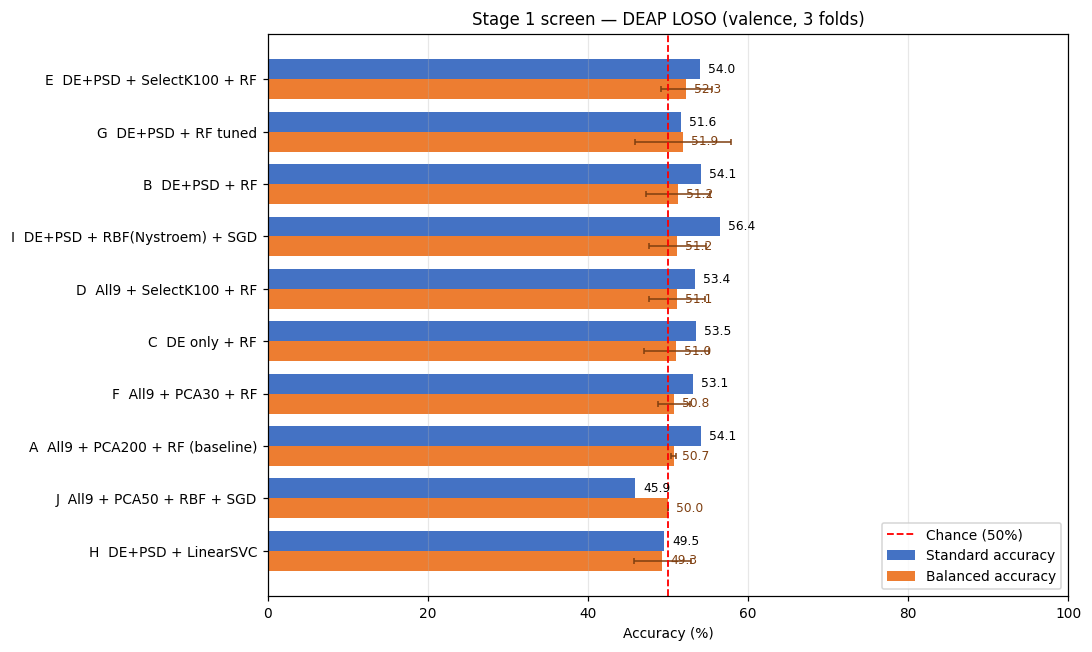

In [11]:
d = s1.sort_values('bal', ascending=True)
yp = np.arange(len(d)); h = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(yp + h/2, d['acc'], h, label='Standard accuracy', color='#4472C4')
ax.barh(yp - h/2, d['bal'], h, label='Balanced accuracy', color='#ED7D31',
        xerr=d['bal_std'], error_kw=dict(ecolor='#7f3f10', capsize=2, lw=1))
ax.axvline(50, color='red', ls='--', lw=1.2, label='Chance (50%)')
ax.set_yticks(yp)
ax.set_yticklabels([f'{v}  {l}' for v, l in zip(d['variant'], d['label'])])
ax.set_xlabel('Accuracy (%)')
ax.set_title(f'Stage 1 screen — DEAP LOSO ({STAGE1_TASK}, {STAGE1_FOLDS} folds)')
ax.set_xlim(0, 100); ax.legend(loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
for i, (a, b) in enumerate(zip(d['acc'], d['bal'])):
    ax.text(a + 1, i + h/2, f'{a:.1f}', va='center', fontsize=8)
    ax.text(b + 1, i - h/2, f'{b:.1f}', va='center', fontsize=8, color='#7f3f10')
plt.tight_layout(); plt.show()

### Graph 2 — Prediction distribution (Stage 1)

Direct evidence of collapse. A single full-width bar means the model emitted one class for every test segment.

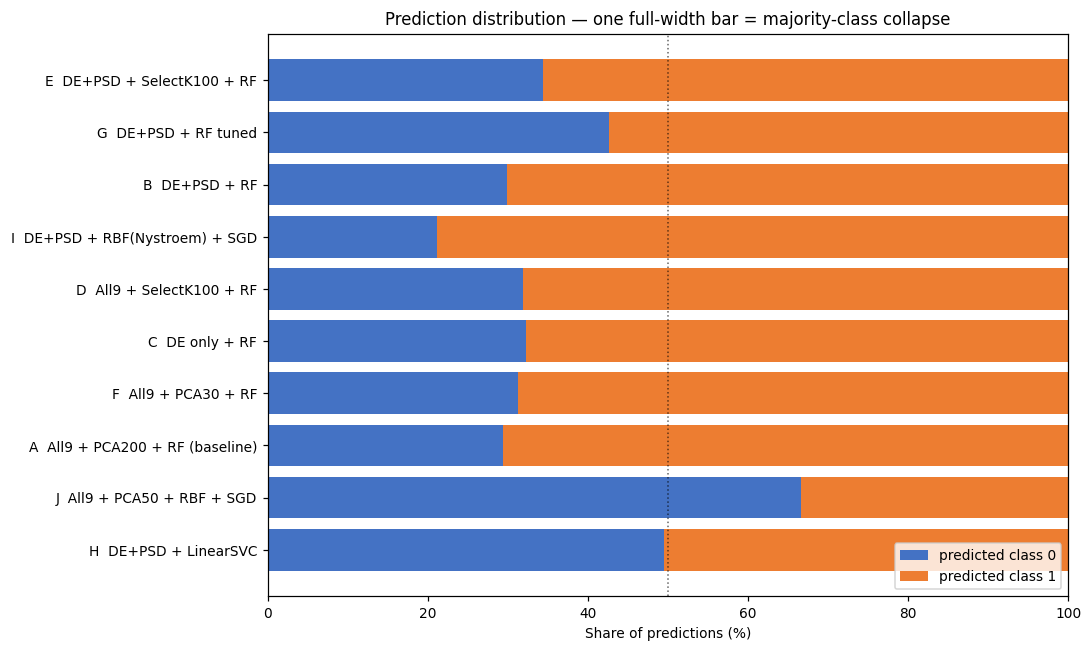

In [12]:
d2 = s1.sort_values('bal', ascending=True)
classes = sorted({c for pdst in d2['pred_dist'] for c in pdst})
colors = ['#4472C4', '#ED7D31', '#70AD47']

fig, ax = plt.subplots(figsize=(10, 6))
left = np.zeros(len(d2))
for ci, cls in enumerate(classes):
    vals   = np.array([pdst.get(cls, 0) for pdst in d2['pred_dist']], dtype=float)
    totals = np.array([sum(pdst.values()) for pdst in d2['pred_dist']], dtype=float)
    pct = vals / totals * 100
    ax.barh(np.arange(len(d2)), pct, left=left,
            label=f'predicted class {cls}', color=colors[ci % len(colors)])
    left += pct
ax.axvline(50, color='black', ls=':', lw=1, alpha=0.6)
ax.set_yticks(np.arange(len(d2)))
ax.set_yticklabels([f'{v}  {l}' for v, l in zip(d2['variant'], d2['label'])])
ax.set_xlabel('Share of predictions (%)')
ax.set_title('Prediction distribution — one full-width bar = majority-class collapse')
ax.set_xlim(0, 100); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

## Section 7 — Select variants for Stage 2

Variants that predict both classes are preferred. The baseline A is always carried forward so Stage 2 contains a like-for-like reference point.

In [15]:
DROP = ['G']          # 1185s per fold — too slow for 15 folds

non_collapsed = (s1[(s1['frac_majority_pred'] <= 0.995) &
                    (~s1['variant'].isin(DROP))]
                 .sort_values('bal', ascending=False))
chosen = list(non_collapsed['variant'].head(STAGE2_TOP_N))

if 'A' not in chosen:
    chosen = chosen[:STAGE2_TOP_N - 1] + ['A']

print(f'Advancing to Stage 2 ({len(chosen)} variants):')
for v in chosen:
    r = s1[s1['variant'] == v].iloc[0]
    print(f'  {v}: {VARIANT_LABELS[v]:34s} stage1 bal = {r["bal"]:.2f}%')
print(f'\nExcluded: {DROP}')

Advancing to Stage 2 (4 variants):
  E: DE+PSD + SelectK100 + RF           stage1 bal = 52.27%
  B: DE+PSD + RF                        stage1 bal = 51.23%
  I: DE+PSD + RBF(Nystroem) + SGD       stage1 bal = 51.17%
  A: All9 + PCA200 + RF (baseline)      stage1 bal = 50.71%

Excluded: ['G']


In [16]:
from sklearn.model_selection import train_test_split

print('WITHIN-SUBJECT sanity check (train and test on the SAME person)')
print('-' * 68)
for sid in [1, 5, 6]:
    m = subject_ids == sid
    Xs, ys = build_X(['DE', 'PSD'])[m], LABELS['valence'][m]
    if len(np.unique(ys)) < 2:
        print(f'  subj {sid}: only one class present, skipped'); continue
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.3,
                                          stratify=ys, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, min_samples_leaf=5,
                                 class_weight='balanced', n_jobs=-1,
                                 random_state=42).fit(Xtr, ytr)
    p = clf.predict(Xte)
    print(f'  subj {sid}:  acc={accuracy_score(yte,p)*100:5.2f}%   '
          f'bal={balanced_accuracy_score(yte,p)*100:5.2f}%')

WITHIN-SUBJECT sanity check (train and test on the SAME person)
--------------------------------------------------------------------
  subj 1:  acc=66.78%   bal=66.79%
  subj 5:  acc=63.99%   bal=60.44%
  subj 6:  acc=75.17%   bal=57.15%


In [17]:
from sklearn.model_selection import train_test_split

print('Per-subject class balance and within-subject learnability')
print('-' * 70)
X_dp = build_X(['DE', 'PSD'])
for sid in [1, 5, 6, 12]:
    m = subject_ids == sid
    Xs, ys = X_dp[m], LABELS['valence'][m]
    bal = ys.mean()
    if len(np.unique(ys)) < 2:
        print(f'  subj {sid}: single class only — skipped'); continue
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.3,
                                          stratify=ys, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, min_samples_leaf=5,
                                 class_weight='balanced', n_jobs=-1,
                                 random_state=42).fit(Xtr, ytr)
    p = clf.predict(Xte)
    print(f'  subj {sid}:  class split={bal*100:5.1f}% high   '
          f'within-subj acc={accuracy_score(yte,p)*100:5.2f}%   '
          f'bal={balanced_accuracy_score(yte,p)*100:5.2f}%')

Per-subject class balance and within-subject learnability
----------------------------------------------------------------------
  subj 1:  class split= 47.5% high   within-subj acc=66.78%   bal=66.79%
  subj 5:  class split= 60.1% high   within-subj acc=63.99%   bal=60.44%
  subj 6:  class split= 75.0% high   within-subj acc=75.17%   bal=57.15%
  subj 12:  class split= 52.6% high   within-subj acc=65.03%   bal=65.40%


In [18]:
y_full = np.load(DATA_DIR / 'y_deap_valence.npy')
a_full = np.load(DATA_DIR / 'y_deap_arousal.npy')
sids_f = np.load(DATA_DIR / 'deap_subject_ids.npy')

SEG_PER_TRIAL, N_TRIALS = 119, 40
rows = []
for sid in np.unique(sids_f):
    m = sids_f == sid
    yv, ya = y_full[m], a_full[m]
    if len(yv) != SEG_PER_TRIAL * N_TRIALS:
        print(f'subj {sid}: unexpected length {len(yv)}')
        continue
    tv = yv.reshape(N_TRIALS, SEG_PER_TRIAL)
    ta = ya.reshape(N_TRIALS, SEG_PER_TRIAL)
    const = (all(len(np.unique(r)) == 1 for r in tv) and
             all(len(np.unique(r)) == 1 for r in ta))
    rows.append({'subject': int(sid),
                 'val_high_trials': int(tv[:, 0].sum()),
                 'aro_high_trials': int(ta[:, 0].sum()),
                 'const_within_trial': const})

tdf = pd.DataFrame(rows)
print(tdf.to_string(index=False))
n = len(tdf) * N_TRIALS
print(f'\nTotal trials:  {n}')
print(f'High valence:  {tdf["val_high_trials"].sum()} ({tdf["val_high_trials"].sum()/n*100:.1f}%)   expected ~50%')
print(f'High arousal:  {tdf["aro_high_trials"].sum()} ({tdf["aro_high_trials"].sum()/n*100:.1f}%)   expected ~50%')
print(f'Labels constant within trial: {tdf["const_within_trial"].all()}')

 subject  val_high_trials  aro_high_trials  const_within_trial
       1               19               24                True
       2               22               24                True
       3               22                8                True
       4               16               16                True
       5               24               19                True
       6               30               17                True
       7               28               25                True
       8               22               23                True
       9               20               24                True
      10               20               22                True
      11               24               15                True
      12               21               33                True
      13               17               34                True
      14               20               27                True
      15               20               19             

## Section 8 — STAGE 2: rank survivors on 15 folds, both tasks

15 folds brings the uncertainty in each mean down to roughly ±2 pp, enough to separate variants differing by ~6 pp or more. Running valence and arousal guards against picking a configuration that only works on one dimension.

**Expected wall time:** ~15–30 minutes.

In [19]:
print(f'STAGE 2 — {len(chosen)} variants x {len(STAGE2_TASKS)} tasks x {STAGE2_FOLDS} folds')
print(f'subjects: {STAGE2_SUBJECTS.tolist()}   parallel folds: {N_JOBS}\n')

stage2 = []
t_all = time.time()
for task in STAGE2_TASKS:
    print(f'--- {task} ---')
    for v in chosen:
        feats, spec = SPEC_BY_VARIANT[v]
        try:
            stage2.append(evaluate_variant(v, feats, spec, STAGE2_SUBJECTS,
                                           task, n_jobs=N_JOBS))
        except Exception as e:
            print(f'  {v:3s} FAILED: {type(e).__name__}: {e}')
    print()

print(f'Stage 2 total: {(time.time()-t_all)/60:.1f} min')

s2 = pd.DataFrame(stage2)
s2['label'] = s2['variant'].map(VARIANT_LABELS)

STAGE 2 — 4 variants x 2 tasks x 15 folds
subjects: [1, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 25, 26, 30, 31]   parallel folds: 8

--- valence ---
  E   valence  dim=  320  acc=54.64%  bal=53.74% ±6.04  f1=0.535  fit= 75.8s  wall= 2.6m  [both classes]
  B   valence  dim=  320  acc=54.51%  bal=53.29% ±5.83  f1=0.527  fit=123.2s  wall= 4.2m  [both classes]
  I   valence  dim=  320  acc=54.16%  bal=51.99% ±4.83  f1=0.489  fit=  2.3s  wall= 0.1m  [both classes]
  A   valence  dim= 3628  acc=53.82%  bal=52.31% ±2.54  f1=0.520  fit=125.5s  wall= 4.2m  [both classes]

--- arousal ---
  E   arousal  dim=  320  acc=55.22%  bal=51.24% ±2.89  f1=0.520  fit= 76.5s  wall= 2.6m  [both classes]
  B   arousal  dim=  320  acc=55.08%  bal=51.08% ±1.71  f1=0.518  fit=129.9s  wall= 4.4m  [both classes]
  I   arousal  dim=  320  acc=58.21%  bal=50.17% ±1.88  f1=0.503  fit=  1.8s  wall= 0.1m  [both classes]
  A   arousal  dim= 3628  acc=55.77%  bal=50.69% ±2.34  f1=0.514  fit=130.9s  wall= 4.4m  [both classe

In [20]:
# mean balanced accuracy across both tasks decides the winner
agg = (s2.groupby('variant')
         .agg(bal_mean=('bal', 'mean'),
              bal_min=('bal', 'min'),
              acc_mean=('acc', 'mean'),
              f1_mean=('f1', 'mean'),
              fit_s=('fit_s', 'mean'),
              dim_in=('dim_in', 'first'))
         .reset_index()
         .sort_values('bal_mean', ascending=False))
agg['label'] = agg['variant'].map(VARIANT_LABELS)

print('Stage 2 — per task')
pv = s2.pivot_table(index='variant', columns='task', values=['bal', 'bal_sem', 'acc'])
print(pv.round(2).to_string())

print('\nStage 2 — combined ranking (mean balanced accuracy over both tasks)')
out = agg[['variant', 'label', 'dim_in', 'acc_mean', 'bal_mean', 'bal_min', 'f1_mean', 'fit_s']].copy()
out.columns = ['Var', 'Configuration', 'Dim', 'Acc %', 'Bal % (mean)', 'Bal % (worst task)', 'F1', 'Fit s']
for c in ['Acc %', 'Bal % (mean)', 'Bal % (worst task)', 'Fit s']:
    out[c] = out[c].round(2)
out['F1'] = out['F1'].round(3)
print(out.to_string(index=False))

WINNER = agg.iloc[0]['variant']
print(f'\nWinner: {WINNER} — {VARIANT_LABELS[WINNER]}')

Stage 2 — per task
            acc             bal         bal_sem        
task    arousal valence arousal valence arousal valence
variant                                                
A         55.77   53.82   50.69   52.31    0.60    0.66
B         55.08   54.51   51.08   53.29    0.44    1.50
E         55.22   54.64   51.24   53.74    0.75    1.56
I         58.21   54.16   50.17   51.99    0.49    1.25

Stage 2 — combined ranking (mean balanced accuracy over both tasks)
Var                 Configuration  Dim  Acc %  Bal % (mean)  Bal % (worst task)    F1  Fit s
  E      DE+PSD + SelectK100 + RF  320  54.93         52.49               51.24 0.528  76.16
  B                   DE+PSD + RF  320  54.80         52.18               51.08 0.522 126.55
  A All9 + PCA200 + RF (baseline) 3628  54.79         51.50               50.69 0.517 128.20
  I  DE+PSD + RBF(Nystroem) + SGD  320  56.19         51.08               50.17 0.496   2.05

Winner: E — DE+PSD + SelectK100 + RF


### Graph 3 — Valence vs arousal (Stage 2)

Checks that the winning configuration holds on both dimensions. A variant strong on one and weak on the other is not a safe choice for the main run.

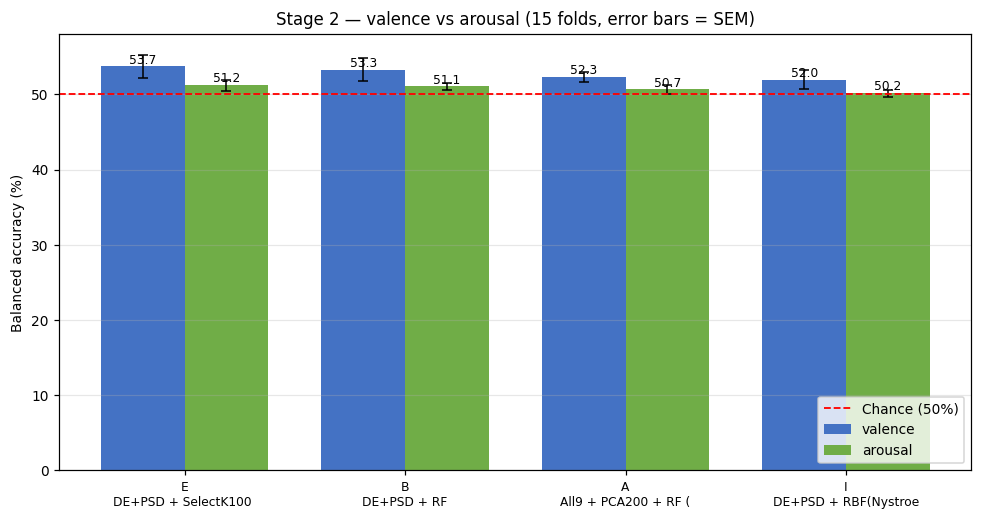

In [21]:
order = agg['variant'].tolist()
xp = np.arange(len(order)); w = 0.38

fig, ax = plt.subplots(figsize=(9, 4.8))
for i, (task, col) in enumerate([('valence', '#4472C4'), ('arousal', '#70AD47')]):
    sub = s2[s2['task'] == task].set_index('variant').reindex(order)
    ax.bar(xp + (i - 0.5) * w, sub['bal'], w, label=task, color=col,
           yerr=sub['bal_sem'], capsize=3, error_kw=dict(lw=1))
    for j, v in enumerate(sub['bal']):
        if not np.isnan(v):
            ax.text(j + (i - 0.5) * w, v + 0.4, f'{v:.1f}', ha='center', fontsize=8)

ax.axhline(50, color='red', ls='--', lw=1.2, label='Chance (50%)')
ax.set_xticks(xp)
ax.set_xticklabels([f'{v}\n{VARIANT_LABELS[v][:20]}' for v in order], fontsize=8)
ax.set_ylabel('Balanced accuracy (%)')
ax.set_title(f'Stage 2 — valence vs arousal ({STAGE2_FOLDS} folds, error bars = SEM)')
ax.legend(loc='lower right'); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### Graph 4 — Stage 1 vs Stage 2 stability

How much each estimate moved when folds went from 3 to 15. Large movement is the empirical justification for not trusting a 3-fold ranking.

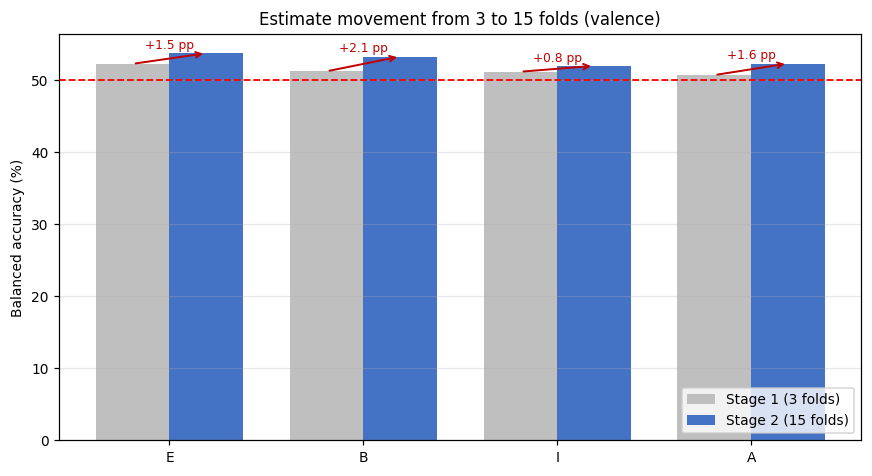

Mean absolute movement: 1.49 pp


In [22]:
rows = []
for v in chosen:
    b1 = s1[s1['variant'] == v]['bal'].iloc[0]
    b2 = s2[(s2['variant'] == v) & (s2['task'] == STAGE1_TASK)]['bal']
    if len(b2):
        rows.append({'variant': v, 'stage1': b1, 'stage2': b2.iloc[0]})
st = pd.DataFrame(rows)

if len(st):
    xp = np.arange(len(st)); w = 0.38
    fig, ax = plt.subplots(figsize=(8, 4.4))
    ax.bar(xp - w/2, st['stage1'], w, label=f'Stage 1 ({STAGE1_FOLDS} folds)', color='#BFBFBF')
    ax.bar(xp + w/2, st['stage2'], w, label=f'Stage 2 ({STAGE2_FOLDS} folds)', color='#4472C4')
    for i, r in st.iterrows():
        ax.annotate('', xy=(i + w/2, r['stage2']), xytext=(i - w/2, r['stage1']),
                    arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.3))
        ax.text(i, max(r['stage1'], r['stage2']) + 0.6,
                f'{r["stage2"] - r["stage1"]:+.1f} pp',
                ha='center', fontsize=8, color='#C00000')
    ax.axhline(50, color='red', ls='--', lw=1.2)
    ax.set_xticks(xp); ax.set_xticklabels(st['variant'])
    ax.set_ylabel('Balanced accuracy (%)')
    ax.set_title(f'Estimate movement from 3 to 15 folds ({STAGE1_TASK})')
    ax.legend(loc='lower right'); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'Mean absolute movement: {(st["stage2"] - st["stage1"]).abs().mean():.2f} pp')
else:
    print('No overlapping variants to compare.')

### Graph 5 — Improvement waterfall vs baseline A

What each change bought, in percentage points of balanced accuracy averaged over both tasks. This is the figure to reuse in the report.

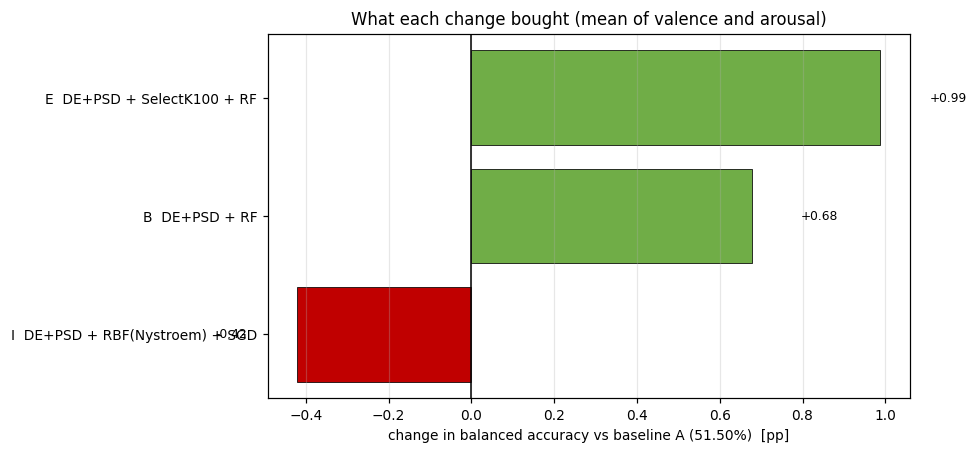

In [23]:
if 'A' in agg['variant'].values:
    base = agg[agg['variant'] == 'A']['bal_mean'].iloc[0]
    w2 = agg[agg['variant'] != 'A'].sort_values('bal_mean')
    deltas = w2['bal_mean'] - base
    cols = ['#70AD47' if x > 0 else '#C00000' for x in deltas]

    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.barh(np.arange(len(w2)), deltas, color=cols, edgecolor='black', lw=0.5)
    ax.axvline(0, color='black', lw=1)
    ax.set_yticks(np.arange(len(w2)))
    ax.set_yticklabels([f'{v}  {VARIANT_LABELS[v]}' for v in w2['variant']])
    ax.set_xlabel(f'change in balanced accuracy vs baseline A ({base:.2f}%)  [pp]')
    ax.set_title('What each change bought (mean of valence and arousal)')
    ax.grid(True, axis='x', alpha=0.3)
    for i, v in enumerate(deltas):
        ax.text(v + (0.12 if v >= 0 else -0.12), i, f'{v:+.2f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('Baseline A not in Stage 2 — waterfall skipped.')

### Graph 6 — Per-subject spread (Stage 2, 15 folds)

Whether gains are uniform across subjects or driven by a couple of easy ones. Wide boxes mean unstable cross-subject behaviour.

/tmp/ipykernel_3737/1114499409.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labs, patch_artist=True, widths=0.6)
/tmp/ipykernel_3737/1114499409.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labs, patch_artist=True, widths=0.6)


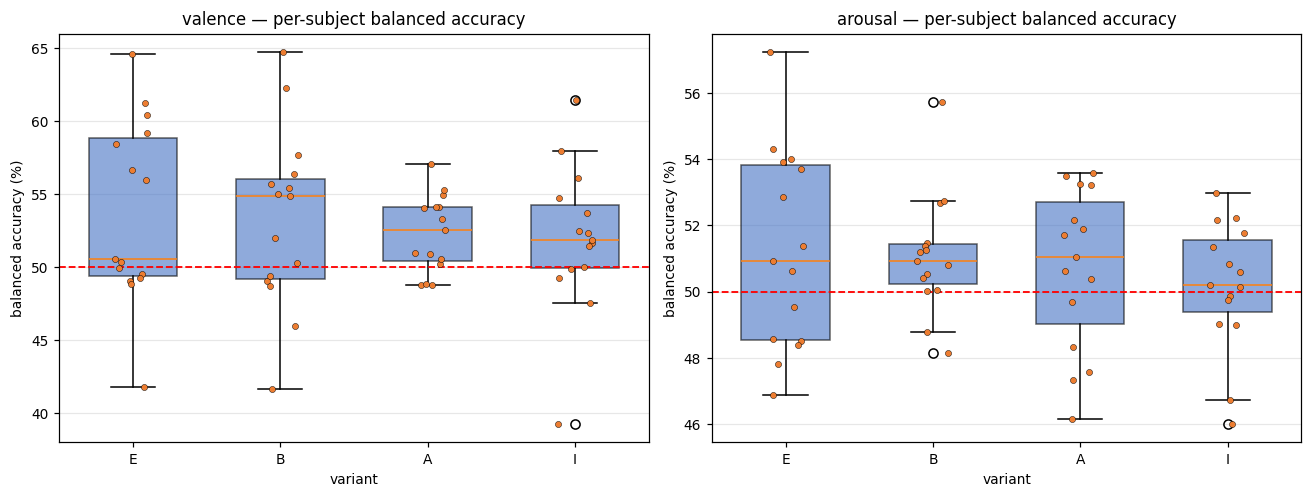

In [24]:
fig, axes = plt.subplots(1, len(STAGE2_TASKS), figsize=(6 * len(STAGE2_TASKS), 4.6),
                         squeeze=False)
for k, task in enumerate(STAGE2_TASKS):
    ax = axes[0][k]
    sub = s2[s2['task'] == task].set_index('variant').reindex(order)
    data = [sub.loc[v, 'per_fold_bal'] for v in order if isinstance(sub.loc[v, 'per_fold_bal'], list)]
    labs = [v for v in order if isinstance(sub.loc[v, 'per_fold_bal'], list)]
    bp = ax.boxplot(data, labels=labs, patch_artist=True, widths=0.6)
    for patch in bp['boxes']:
        patch.set_facecolor('#4472C4'); patch.set_alpha(0.6)
    for i, vals in enumerate(data):
        jitter = np.random.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), i + 1) + jitter, vals, s=16,
                   color='#ED7D31', zorder=3, edgecolors='black', linewidths=0.3)
    ax.axhline(50, color='red', ls='--', lw=1.2)
    ax.set_title(f'{task} — per-subject balanced accuracy')
    ax.set_xlabel('variant'); ax.set_ylabel('balanced accuracy (%)')
    ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### Graph 7 — Which feature families does SelectKBest pick?

Fits `SelectKBest(f_classif, k=100)` on the training portion of one fold with all 9 features, then reports how many of the 100 chosen columns came from each family. The right panel normalises by family size — a small family with a high selection rate is punching above its weight.

 feature  dims  selected  share_of_100  selection_rate
     PLV  2480        31          31.0            1.25
      DE   160        29          29.0           18.12
     PSD   160        21          21.0           13.12
    CORR   496        11          11.0            2.22
    DASM    70         5           5.0            7.14
    RASM    70         2           2.0            2.86
 ENTROPY    32         1           1.0            3.12
TEMPORAL   128         0           0.0            0.00
 FRACTAL    32         0           0.0            0.00


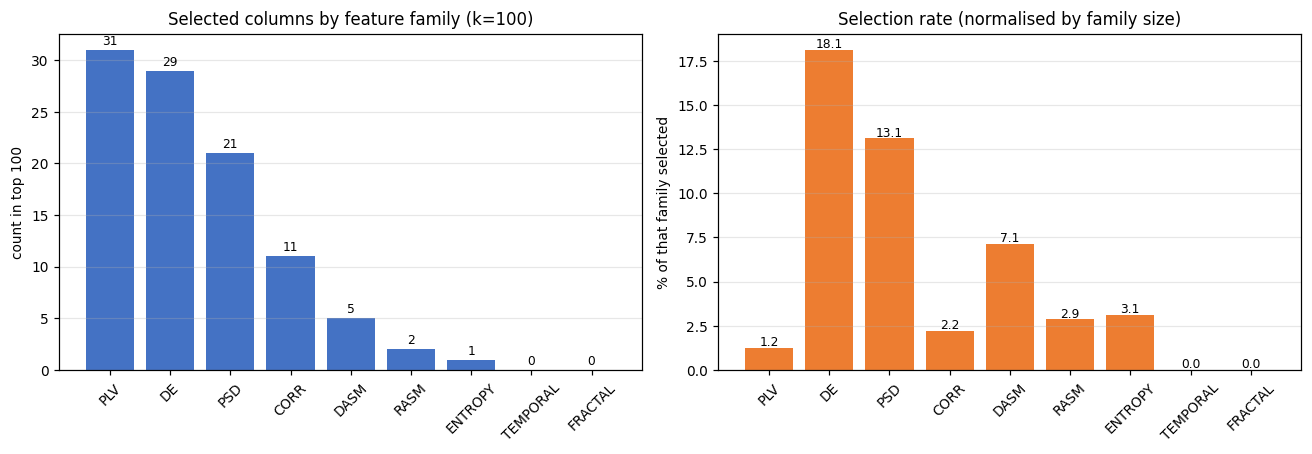

In [25]:
K_SEL = 100
X_all = build_X(ALL_FEATURES)
idx_map = feature_index_map(ALL_FEATURES)

sid0 = STAGE2_SUBJECTS[0]
tr = subject_ids != sid0
sel = SelectKBest(f_classif, k=K_SEL).fit(X_all[tr], LABELS[STAGE1_TASK][tr])
chosen_cols = np.where(sel.get_support())[0]

rows = []
for fname, (a, b) in idx_map.items():
    n_sel = int(((chosen_cols >= a) & (chosen_cols < b)).sum())
    size = b - a
    rows.append({'feature': fname, 'dims': size, 'selected': n_sel,
                 'share_of_100': n_sel / K_SEL * 100,
                 'selection_rate': n_sel / size * 100})
sel_df = pd.DataFrame(rows).sort_values('selected', ascending=False)
print(sel_df.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(sel_df['feature'], sel_df['selected'], color='#4472C4')
axes[0].set_ylabel(f'count in top {K_SEL}')
axes[0].set_title(f'Selected columns by feature family (k={K_SEL})')
axes[0].tick_params(axis='x', rotation=45); axes[0].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(sel_df['selected']):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=8)

axes[1].bar(sel_df['feature'], sel_df['selection_rate'], color='#ED7D31')
axes[1].set_ylabel('% of that family selected')
axes[1].set_title('Selection rate (normalised by family size)')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(True, axis='y', alpha=0.3)
for i, v in enumerate(sel_df['selection_rate']):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

### Graph 8 — PCA explained variance

How many components the 3,628-dim space actually needs. If 30 components already reach 95%, PCA(200) was carrying mostly noise.

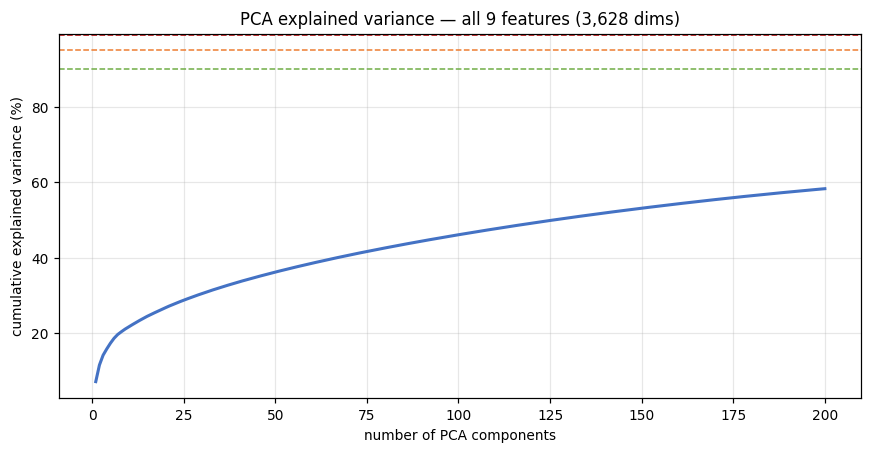

17789

In [26]:
probe_idx = np.random.RandomState(SEED).choice(len(X_all),
                                               size=min(8000, len(X_all)), replace=False)
pca_probe = PCA(n_components=200, random_state=SEED).fit(X_all[probe_idx])
cum = np.cumsum(pca_probe.explained_variance_ratio_) * 100

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(np.arange(1, len(cum) + 1), cum, lw=2, color='#4472C4')
for thr, col in [(90, '#70AD47'), (95, '#ED7D31'), (99, '#C00000')]:
    ax.axhline(thr, color=col, ls='--', lw=1)
    if (cum >= thr).any():
        n_need = int(np.argmax(cum >= thr) + 1)
        ax.axvline(n_need, color=col, ls=':', lw=1)
        ax.text(n_need + 2, thr - 4, f'{thr}% at {n_need} comps', color=col, fontsize=8)
ax.set_xlabel('number of PCA components')
ax.set_ylabel('cumulative explained variance (%)')
ax.set_title('PCA explained variance — all 9 features (3,628 dims)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

del X_all; gc.collect()

### Graph 9 — Runtime vs balanced accuracy

Cost/benefit. Upper-left is the desirable region: high balanced accuracy, low fit time.

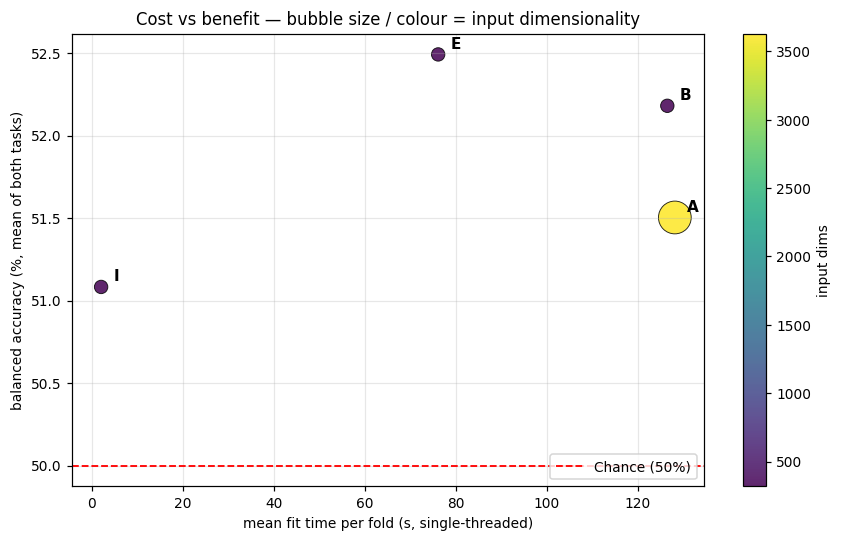

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
sizes = 40 + (agg['dim_in'] / agg['dim_in'].max()) * 420
sc = ax.scatter(agg['fit_s'], agg['bal_mean'], s=sizes, c=agg['dim_in'],
                cmap='viridis', alpha=0.85, edgecolors='black', linewidths=0.6)
for _, r in agg.iterrows():
    ax.annotate(r['variant'], (r['fit_s'], r['bal_mean']),
                textcoords='offset points', xytext=(8, 4),
                fontsize=10, fontweight='bold')
ax.axhline(50, color='red', ls='--', lw=1.2, label='Chance (50%)')
ax.set_xlabel('mean fit time per fold (s, single-threaded)')
ax.set_ylabel('balanced accuracy (%, mean of both tasks)')
ax.set_title('Cost vs benefit — bubble size / colour = input dimensionality')
ax.grid(True, alpha=0.3); ax.legend(loc='lower right')
plt.colorbar(sc, ax=ax, label='input dims')
plt.tight_layout(); plt.show()

## Section 9 — Save results

Writes both stages to CSV plus a text summary, so the winning configuration can be carried into `02_baselines_classical_colab.ipynb` and quoted in the report.

In [28]:
s1.drop(columns=['pred_dist']).to_csv(DATA_DIR / 'experiment_stage1_screen.csv', index=False)
s2.drop(columns=['pred_dist']).to_csv(DATA_DIR / 'experiment_stage2_rank.csv', index=False)

txt = DATA_DIR / 'experiment_summary.txt'
win_feats, win_spec = SPEC_BY_VARIANT[WINNER]
win_rows = s2[s2['variant'] == WINNER]

with open(txt, 'w') as f:
    f.write('Baseline optimisation experiment — DEAP LOSO\n')
    f.write('=' * 78 + '\n\n')
    f.write(f'Cores used:   {N_CORES}   (outer parallel folds: {N_JOBS})\n')
    f.write(f'Subsample:    every {SUBSAMPLE}th segment ({len(subject_ids)} segments)\n')
    f.write(f'Stage 1:      {STAGE1_FOLDS} folds, {STAGE1_TASK}, subjects {STAGE1_SUBJECTS.tolist()}\n')
    f.write(f'Stage 2:      {STAGE2_FOLDS} folds, {STAGE2_TASKS}, subjects {STAGE2_SUBJECTS.tolist()}\n\n')

    f.write('STAGE 1 — screen (all variants, ranked by balanced accuracy)\n')
    f.write('-' * 78 + '\n')
    f.write(f'{"Var":4s} {"Configuration":32s} {"Dim":>6s} {"Acc%":>7s} {"Bal%":>7s} {"MajPred":>8s}\n')
    for _, r in s1.iterrows():
        f.write(f'{r["variant"]:4s} {r["label"][:32]:32s} {r["dim_in"]:6d} '
                f'{r["acc"]:7.2f} {r["bal"]:7.2f} {r["frac_majority_pred"]:8.3f}\n')

    f.write('\nSTAGE 2 — rank (survivors, per task)\n')
    f.write('-' * 78 + '\n')
    f.write(f'{"Var":4s} {"Task":9s} {"Acc%":>7s} {"Bal%":>7s} {"SEM":>6s} {"F1":>7s}\n')
    for _, r in s2.sort_values(['variant', 'task']).iterrows():
        f.write(f'{r["variant"]:4s} {r["task"]:9s} {r["acc"]:7.2f} '
                f'{r["bal"]:7.2f} {r["bal_sem"]:6.2f} {r["f1"]:7.3f}\n')

    f.write('\nSTAGE 2 — combined ranking\n')
    f.write('-' * 78 + '\n')
    for _, r in agg.iterrows():
        f.write(f'{r["variant"]:4s} {r["label"][:34]:34s} '
                f'bal_mean={r["bal_mean"]:6.2f}  worst_task={r["bal_min"]:6.2f}\n')

    f.write(f'\nWINNER: {WINNER} — {VARIANT_LABELS[WINNER]}\n')
    f.write(f'  features:  {"+".join(win_feats)}\n')
    f.write(f'  spec:      {json.dumps(win_spec)}\n')
    f.write(f'  input dim: {sum(FEATURE_DIMS[x] for x in win_feats)}\n')
    for _, r in win_rows.iterrows():
        f.write(f'  {r["task"]:9s} bal = {r["bal"]:.2f}% ± {r["bal_sem"]:.2f} (SEM), '
                f'acc = {r["acc"]:.2f}%\n')

print(f'Saved: experiment_stage1_screen.csv')
print(f'Saved: experiment_stage2_rank.csv')
print(f'Saved: {txt.name}\n')
print(open(txt).read())

Saved: experiment_stage1_screen.csv
Saved: experiment_stage2_rank.csv
Saved: experiment_summary.txt

Baseline optimisation experiment — DEAP LOSO

Cores used:   8   (outer parallel folds: 8)
Subsample:    every 5th segment (30464 segments)
Stage 1:      3 folds, valence, subjects [1, 5, 6]
Stage 2:      15 folds, ['valence', 'arousal'], subjects [1, 5, 6, 9, 10, 12, 13, 14, 16, 17, 18, 25, 26, 30, 31]

STAGE 1 — screen (all variants, ranked by balanced accuracy)
------------------------------------------------------------------------------
Var  Configuration                       Dim    Acc%    Bal%  MajPred
E    DE+PSD + SelectK100 + RF            320   54.03   52.27    0.657
G    DE+PSD + RF tuned                   320   51.65   51.87    0.573
B    DE+PSD + RF                         320   54.13   51.23    0.701
I    DE+PSD + RBF(Nystroem) + SGD        320   56.44   51.17    0.789
D    All9 + SelectK100 + RF             3628   53.36   51.10    0.681
C    DE only + RF                 

## Section 10 — How to read the outcome

**A DE-only or DE+PSD variant wins clearly** — PLV's 2,480 dims were diluting the signal. Carry that feature subset into the main notebook and cite the ablation as evidence for the feature choice. Graph 7 supports this independently.

**SelectKBest beats its PCA counterpart** — tree models prefer raw discriminative columns to rotated components. Graph 7 then also names *which* families matter, which is directly quotable in the report.

**A Nystroem RBF variant wins** — the decision boundary is nonlinear, so the RBF-SVM figures in the SOTA table were a fair target. Report it as a Nystroem approximation, not as a full RBF-SVM.

**Everything stays pinned near 50% balanced accuracy** — the handcrafted feature space genuinely does not separate emotion across subjects at threshold 5.0. That reproduces Sadegh-Zadeh et al. (2026) independently and is the correct motivation for the end-to-end models in the next notebook. Report it as a finding, not a failure.

**If Graph 4 shows large movement between stages** — say it plainly in the report: small-fold estimates on DEAP LOSO are unstable, which is why the final numbers use all 32 folds.

### Next step

Copy the winning spec into Section 1 and Section 6 of `02_baselines_classical_colab.ipynb`, set `SUBSAMPLE = None`, run all 32 folds on all 3 label types, then move to `03_baselines_deep_colab.ipynb` for CNN / LSTM / BiLSTM on raw signals.